# Notebook 01 · Data Quality, Proxies, and Gap Characterization

This notebook executes **Phase A, Step 1** of the `heritageshm` pipeline:

1. **Sensor Loading** — Load the preprocessed sensor CSV from Notebook 00.
2. **Proxy Loading** — Explicitly load specific environmental proxies (e.g. Skin Temperature, Air Temp).
3. **Alignment** — Resample and synchronize multiple proxies onto the sensor index.
4. **Gap Characterization** — Classify missing data and diagnose gap taxonomy.
5. **Save** — Export the aligned, cleaned dataset to `/data/interim/aligned/`.

In [1]:
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from heritageshm.dataloader import load_preprocessed_sensor, load_proxy_data, save_interim_data
from heritageshm.preprocessing import align_multiple_proxies
from heritageshm.diagnostics import characterize_gaps


## Step 1 · Load Preprocessed Sensor Data

In [2]:
# Specify which station to analyze here
TARGET_STATION = 'st02'

SENSOR_FILE = f'data/interim/sensor/{TARGET_STATION}_preprocessed.csv'
df_sensor = load_preprocessed_sensor(SENSOR_FILE)

print(f"Loaded {TARGET_STATION} sensor dataset: {df_sensor.shape}")
df_sensor.head(3)

Loaded st02 sensor dataset: (116562, 4)


,charge,temp,hum,absinc
datetime,,,,
2018-07-25 23:40:00,3.49,21.750,45.115,0.000
2018-07-26 00:00:00,3.47,21.555,45.155,0.350
2018-07-26 00:20:00,3.47,21.365,45.040,0.175


## Step 2 · Load Proxies Individually
Fetch any environmental proxy data you want to associate with the sensor.

In [3]:
PROXY_FILE = 'data/raw/proxies/oikolab_weather.csv'
import pandas as pd

# Peek at the columns without loading the entire file into memory
sample_df = pd.read_csv(PROXY_FILE, nrows=0)
print("Available columns in the proxy file:")
for col in sample_df.columns:
    print(f"  - {col}")

Available columns in the proxy file:
  - datetime (UTC)
  - coordinates (lat,lon)
  - model (name)
  - model elevation (surface)
  - utc_offset (hrs)
  - temperature (degC)
  - dewpoint_temperature (degC)
  - relative_humidity (0-1)
  - wetbulb_temperature (degC)
  - skin_temperature (degC)
  - urban_temperature (degC)
  - wind_speed (m/s)
  - wind_direction (deg)
  - total_cloud_cover (0-1)
  - total_precipitation (mm of water equivalent)
  - surface_solar_radiation (W/m^2)
  - surface_thermal_radiation (W/m^2)


In [4]:
# === USER INPUT ===
PROXY_FILE = 'data/raw/proxies/oikolab_weather.csv'

# Select only the proxy columns you want to use downstream.
# Remove or comment out any you don't need.
PROXY_COLS = [
    'temperature (degC)',
    'dewpoint_temperature (degC)',
    'relative_humidity (0-1)',
    'wetbulb_temperature (degC)',
    'skin_temperature (degC)',
    'urban_temperature (degC)',
    # 'wind_speed (m/s)',
    # 'wind_direction (deg)',
    # 'total_cloud_cover (0-1)',
    # 'total_precipitation (mm of water equivalent)',
    'surface_solar_radiation (W/m^2)',
    'surface_thermal_radiation (W/m^2)',
]
# ==================

# Metadata columns to always drop
META_COLS = ['coordinates (lat,lon)', 'model (name)', 
             'model elevation (surface)', 'utc_offset (hrs)']

# Load
df_proxy = pd.read_csv(PROXY_FILE, 
                       parse_dates=['datetime (UTC)'], 
                       index_col='datetime (UTC)')
df_proxy.index.name = 'datetime'

# Drop metadata, keep only selected signals
df_proxy = df_proxy.drop(columns=[c for c in META_COLS if c in df_proxy.columns])
df_proxy = df_proxy[[c for c in PROXY_COLS if c in df_proxy.columns]]

print(f"Loaded proxy dataset: {df_proxy.shape}")
print(f"Date range: {df_proxy.index.min()} → {df_proxy.index.max()}")
display(df_proxy.head(3))

# Build the proxies_dict expected by align_multiple_proxies()
proxies_dict = {'oikolab': df_proxy}
print(f"\nLoaded {len(proxies_dict)} proxy dataset(s).")


Loaded proxy dataset: (72628, 8)
Date range: 2018-01-01 00:00:00 → 2026-04-16 21:00:00


,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,
2018-01-01 00:00:00,7.15,5.91,0.92,6.28,6.29,7.14,0.0,320.89
2018-01-01 01:00:00,7.97,6.58,0.91,7.01,6.72,7.55,0.0,335.55
2018-01-01 02:00:00,7.89,6.05,0.88,6.67,7.42,7.54,0.0,336.98



Loaded 1 proxy dataset(s).


## Step 3 · Resampling and Alignment
Using `align_multiple_proxies`, we resample all defined proxies to match the desired monitoring frequency.

In [5]:
TARGET_FREQ = 'h' # Hourly

if proxies_dict:
    df_aligned = align_multiple_proxies(df_sensor, proxies_dict, resample_freq=TARGET_FREQ, add_prefix=False)
else:
    print("No proxies loaded. Proceeding with sensor data only.")
    df_aligned = df_sensor.resample(TARGET_FREQ).mean()

df_aligned.head(3)

Resampling sensor data to h...
Complete index: 57278 time steps (2018-07-25 23:00:00 → 2025-02-05 12:00:00)
Sensor NaN rows (gaps): 17503
Resampling proxy 'oikolab' to h...
Merging 'oikolab'...
Final aligned dataset contains 57278 rows.


,charge,temp,hum,absinc,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,,,,,
2018-07-25 23:00:00,3.490000,21.750000,45.115000,0.000000,19.11,14.68,0.75,16.13,18.01,22.94,0.0,340.73
2018-07-26 00:00:00,3.473333,21.356667,44.898333,0.550000,18.76,14.93,0.78,16.15,17.32,22.55,0.0,338.83
2018-07-26 01:00:00,3.470000,20.861667,45.828333,1.816667,18.62,15.05,0.80,16.17,16.76,22.25,0.0,339.00


## Step 4 · Gap Characterization and Final Save
Diagnose the gaps, then save the unified dataset for analysis.


--- Gap Taxonomy for 'absinc' ---
Total Gaps Detected: 7
Average Gap Length:  2108.14 time steps
Maximum Gap Length:  10281 time steps
Diagnosis: High likelihood of structured, contiguous outages (MNAR/MAR).
Recommendation: Advanced imputation (e.g., BiLSTM or XGBoost) required.


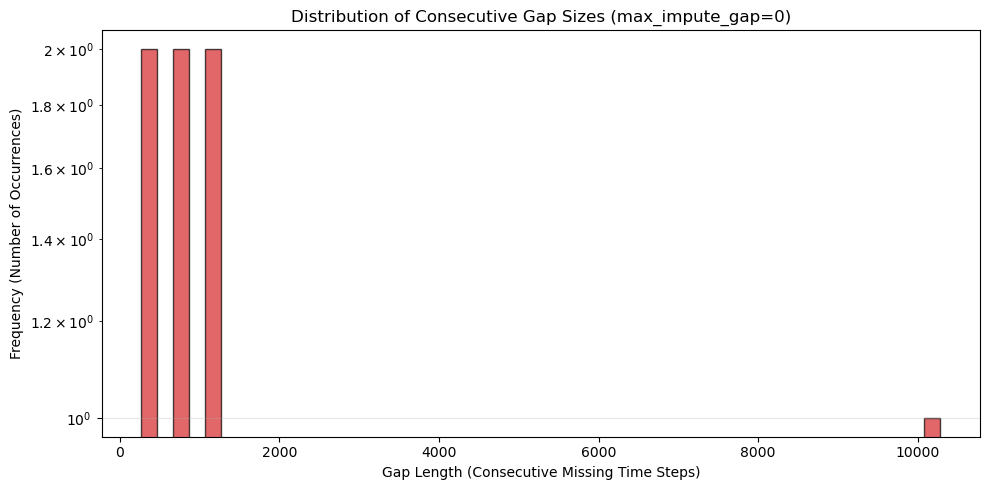

Interim data successfully saved to data/interim/aligned/st02_aligned_dataset.csv


In [17]:
TARGET_COL = 'absinc'  # The main signal to check for gaps


try:
    df_aligned, gap_stats, gap_lengths = characterize_gaps(df_aligned, target_col=TARGET_COL, max_impute_gap=0)
except Exception as e:
    print(f"Gap characterization skipped or failed: {e}")
OUTPUT_PATH = f'data/interim/aligned/{TARGET_STATION}_aligned_dataset.csv'
save_interim_data(df_aligned, OUTPUT_PATH)

In [ ]:
list(df_aligned)